In this section we will simulate **a random walk** on the 2D Torus on $(\mathbb{Z}/N\mathbb{Z})^2$ and then estimate the constant $\tau_{mix}$ 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [114]:
# We first define the constants
p = np.sqrt(0.5)
N = 64
iteration_count = 5000
number_deltas = 10
x, y = 0, 0

In this chain, we go right with probability $p$ and up with probability $1-p$.
We pick the function $g(x,y) = x+y$

In [115]:
# step transition probabilities
def take_step(x, y):
    generated_prob = np.random.random()

    if generated_prob > p:
        return (x+1) % N, y 
    else:
        return x, (y+1) % N

def g(x, y):
    return np.add(x, y)

# compute delta
def g_mean(x_list, y_list, g=g):
    return np.absolute(np.mean(g(x_list, y_list)) - (N-1))

We compute $\Delta_n = \sqrt{\bar{W}}$, where we define $W$ as
\begin{equation}
| \frac{1}{n}\sum\limits_{i=1}^{n-1}g(X_i) - \mathbb{E}[g(X)] |
\end{equation}


In [116]:
# compute an individual delta run
def compute_delta(x, y):
    x_list = []
    y_list = []
    g_mean_list = []
    delta_list = []

    for i in range(iteration_count):
        x, y = take_step(x, y)
        x_list.append(x)
        y_list.append(y)
        g_mean_list.append(g_mean(x_list, y_list))
        delta_list.append(np.mean(g_mean_list))
    return delta_list

In [117]:
# run multiple deltas using the function above and compute their empirical mean (W bar)
deltas = []
for j in range(number_deltas):
    deltas.append(compute_delta(0, 0))
delta_list = []
for i in range(iteration_count):
    sum = 0
    for delta_idx in range(number_deltas):
        sum += deltas[delta_idx][i]
    delta_list.append(np.sqrt(sum/number_deltas))

Now we plot $\Delta_n$ against $\sqrt{\frac{4\tau}{n}}$, where 

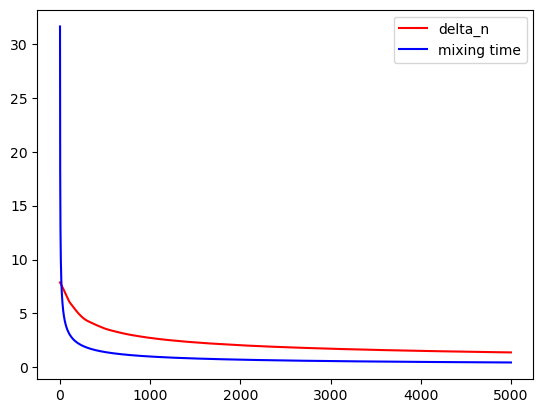

In [121]:
plt.plot(range(iteration_count), delta_list, c="r", label="delta_n")
plt.plot(range(iteration_count), [np.sqrt(1000/n) for n in range(1, iteration_count+1)], c="b", label="mixing time")
plt.legend()